## PyTorch

### Core components of pyTorch
pyTorch contains three core componnets as follows:
- Tensor library: implements tensor
- Automatic differentiation engine: enables automatic computation of tensor operations
- Deep Learning library: provides modular, flexible and efficient building blocks for DL

In [2]:
import torch
print(f"pyTorch version installed: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

pyTorch version installed: 2.9.1+cu130
CUDA available: True


#### 1.1 Tensor Library
- Tensor represents a mathematical concept that generalizes vectors and matrices to potentially higher dimensions

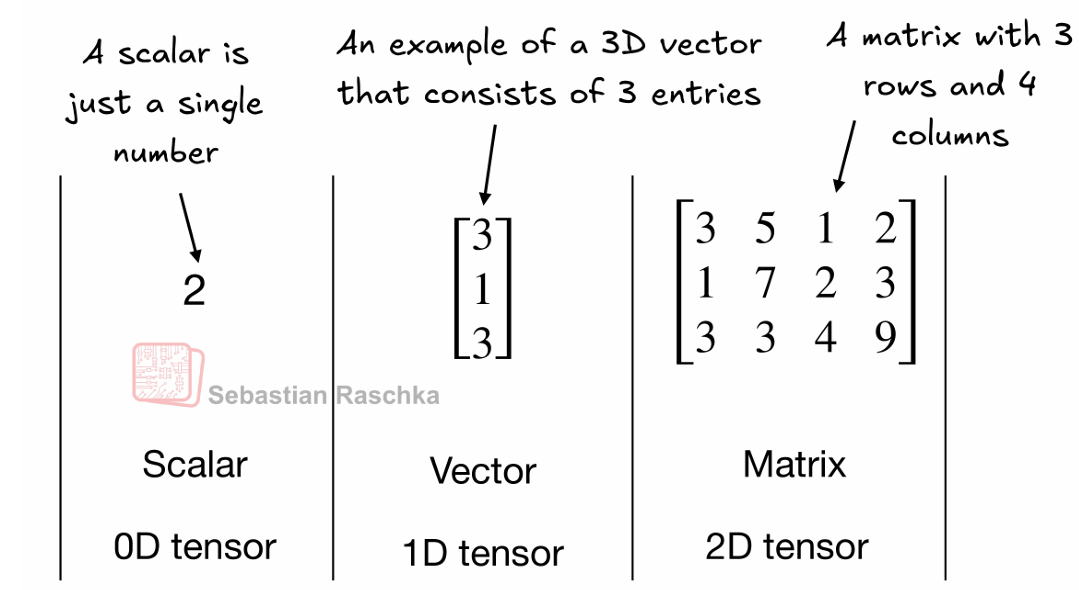

In [7]:
# create a 0D tensor (scalar) from a Python integer
tensor0d = torch.tensor(1)
print(f"0D Tensor {tensor0d} data type is {tensor0d.dtype}\n")

# create a 1D tensor (vector) from a Python list
tensor1d = torch.tensor([1, 2, 3])
print(f"1D Tensor {tensor1d} data type is {tensor1d.dtype}\n")

# create a 2D tensor from a nested Python list
tensor2d = torch.tensor([[1, 2, 1], [3, 4, 1]])
print(f"2D Tensor {tensor2d} data type is {tensor2d.dtype}\n")

# create a 3D tensor from a nested Python list
tensor3d = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
print(f"3D Tensor {tensor3d} data type is {tensor3d.dtype}")

0D Tensor 1 data type is torch.int64

1D Tensor tensor([1, 2, 3]) data type is torch.int64

2D Tensor tensor([[1, 2, 1],
        [3, 4, 1]]) data type is torch.int64

3D Tensor tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]]) data type is torch.int64


In [8]:
# the datatype of tensor can be changed using `.to` method in torch
tensor1d = tensor1d.to(torch.float32)
print(f"1D Tensor {tensor1d} data type is {tensor1d.dtype}")

1D Tensor tensor([1., 2., 3.]) data type is torch.float32


In [13]:
# Common tensor operations

print(f"Size of tensor2d is {tensor2d.shape}\n")        # .shape method returns the size of the tensor 
print(f"Size of tensor3d is {tensor3d.shape}\n")

# the tensor size of the tensor can be changed using .reshape method
reshaped_tensor2d = tensor2d.reshape(3, 2)
print(f"The tensor \n{tensor2d}\nis changed to \n{reshaped_tensor2d}\nwith size {reshaped_tensor2d.shape}")

# reshaping tensor is also acheived by using .view method
print(f"The tensor \n{reshaped_tensor2d}\nis changed to \n{reshaped_tensor2d.view(2,3)}\nwith size {reshaped_tensor2d.view(2,3).shape}")

Size of tensor2d is torch.Size([2, 3])

Size of tensor3d is torch.Size([2, 2, 2])

The tensor 
tensor([[1, 2, 1],
        [3, 4, 1]])
is changed to 
tensor([[1, 2],
        [1, 3],
        [4, 1]])
with size torch.Size([3, 2])
The tensor 
tensor([[1, 2],
        [1, 3],
        [4, 1]])
is changed to 
tensor([[1, 2, 1],
        [3, 4, 1]])
with size torch.Size([2, 3])


In [14]:
# transpose of tensor is obtained by following syntax `tensor_name.T`
print(f"The transpose of \n{reshaped_tensor2d}\nis \n{reshaped_tensor2d.T}")

The transpose of 
tensor([[1, 2],
        [1, 3],
        [4, 1]])
is 
tensor([[1, 1, 4],
        [2, 3, 1]])


In [15]:
# matrix multiplication is acheived using `matmul` method as tensor1.matmul(tensor2) or using `@`
print(f"The result of matrix multiplication of trnsor2d and its transpose is \n{tensor2d.matmul(tensor2d.T)}")

The result of matrix multiplication of trnsor2d and its transpose is 
tensor([[ 6, 12],
        [12, 26]])


#### 1.2 Automatic differention engine 
- It provides functions to compute gradients in dynamic computational graphs automatically
- A computational graph is a directed graph that allows user to express and visualize mathematical expressions

In [17]:
# forward pass (prediction step) of a simple logistic regression classifier
import torch.nn.functional as F

y = torch.tensor([1.0])     # label
xi = torch.tensor([1.1])       # parameter
wi = torch.tensor([2.2])       # weight
b = torch.tensor([0.0])        # bias

z = wi * xi + b
a = torch.sigmoid(z)        # sigmoid activation function

loss = F.binary_cross_entropy(a, y)
print(f"loss value for iteration is: {loss}")

loss value for iteration is: 0.0851878821849823


In [ ]:
# using autograd to find gradient for backpropagation
import torch.nn.functional as F
from torch.autograd import grad

y = torch.tensor([1.0])     # label
xi = torch.tensor([1.1])       # parameter
wi = torch.tensor([2.2], requires_grad=True)       # weight with gradient requies input True 
b = torch.tensor([0.0], requires_grad=True)        # bias with gradient requies input True

z = wi * xi + b
a = torch.sigmoid(z)        # sigmoid activation function

loss = F.binary_cross_entropy(a, y)
print(f"loss value for iteration is: {loss}")

# calculating gradients of loss w.r.t wi and bias [dl/dwi & dl/db]
grad_dl_dw = grad(loss, wi, retain_graph=True)      # pytorch deletes the computational graph used by default which is overridden using`retain_graph` parameter
grad_dl_db = grad(loss, b, retain_graph=True)

print(f"gradients computed using grad method: {grad_dl_dw} & {grad_dl_db}\n")

# gradient computation can be automated by using `.backward` method in autograd
loss.backward()
print(f"gradients computed using backward method: {wi.grad} & {b.grad} & {xi.grad}")
# xi is not set True for gradient computation hence gives None value for gradient

loss value for iteration is: 0.0851878821849823
gradients computed using grad method: (tensor([-0.0898]),) & (tensor([-0.0817]),)

gradients computed using backward method: tensor([-0.0898]) & tensor([-0.0817]) & None


#### 1.3 Deep Learning Library
- When implementing a neural network in PyTorch, we typically inherits the `torch.nn.Module` class which has `__init__` and `forward` methods to define our own custom network architecture.
- This `Module` base class provides a lot of functionality, making it easier to build and train models.
- For instance, it allows us to encapsulate layers and operations and keep track of the model’s parameters.

##### 1.3.1 Custom Neural network structure using Module class
- The network layers are defined in the `__init__` constructor and specify how they interact in the *forward* method
- The `forward` method describes how the input data passes through the network and comes together as a computation graph
- The `backward` method is automated by *autograd* is used during training to compute gradients of the loss function with respect to the model parameters

In [43]:
from torch.nn.modules import Module

# MLP with two hidden layers (total 5 layers including activation layers and output layer excluding input layer)
class NeuralNetwork(Module):
    # the structure of the neural network is defined in __init__ method
    def __init__(self, num_inputs, num_outputs):
        super().__init__()

        self.layers = torch.nn.Sequential(
            # 1st hidden layer
            torch.nn.Linear(num_inputs, 30),
            torch.nn.ReLU(),    # activation function

            # 2nd hidden layer
            torch.nn.Linear(30, 20),
            torch.nn.ReLU(),

            # Output layer
            torch.nn.Linear(20, num_outputs)
        )
    
    def forward(self, x):
        logits = self.layers(x)
        return logits

In [44]:
model = NeuralNetwork(50, 3)
print(f"Neural network model structure:\n{model}")

Neural network model structure:
NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)


Sequential: 
- For a series of layers that we want to execute in a specific order, instantiating as `self.layers = Sequential(...)` in the `__init__` constructor, we just have to call the self.layers instead of calling each layer individually in the NeuralNetwork’s forward method

Linear: 
- A linear layer multiplies the inputs with a weight matrix and adds a bias vector
- This is sometimes also referred to as a feedforward or fully connected layer

In [45]:
# calculating trainable parameters in the model(weights and biases for which gradients are computed in backpropagation)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"The number of trainable parameters are: {num_params}")

The number of trainable parameters are: 2213


In [46]:
# Accessing weights and biases of the model
# activation layers [1] & [3] don't have any weights or biases

# weights of first hidden layer
print(f"Shape of weights[0]: {model.layers[0].weight.shape}\n{model.layers[0].weight}\n")
print(f"Shape of bias[0]: {model.layers[0].bias.shape}\n{model.layers[0].bias}")

# weights of second hidden layer
print(f"Shape of weights[2]: {model.layers[2].weight.shape}\n{model.layers[2].weight}\n")
print(f"Shape of bias[2]: {model.layers[2].bias.shape}\n{model.layers[2].bias}")

# weights of output layer
print(f"Shape of weights[4]: {model.layers[4].weight.shape}\n{model.layers[4].weight}\n")
print(f"Shape of bias[4]: {model.layers[4].bias.shape}\n{model.layers[4].bias}")

Shape of weights[0]: torch.Size([30, 50])
Parameter containing:
tensor([[-1.3438e-04,  1.2480e-01,  5.5528e-02,  ...,  2.0169e-03,
          9.2543e-02, -4.1707e-02],
        [-4.4978e-02,  1.2299e-02,  7.9640e-02,  ..., -1.1897e-02,
         -5.4820e-02, -6.1487e-02],
        [ 1.3595e-01,  4.9931e-02,  9.3271e-03,  ..., -7.8751e-02,
         -4.8154e-02,  6.8859e-02],
        ...,
        [-8.4923e-02,  2.6316e-02, -8.5415e-02,  ...,  5.3689e-02,
         -1.9554e-03,  3.2166e-02],
        [ 7.7929e-02,  1.1063e-01, -4.8065e-02,  ...,  3.9010e-02,
          1.3569e-01,  8.6351e-02],
        [-7.5416e-04, -1.1251e-02, -5.2671e-02,  ...,  2.7388e-02,
         -4.6842e-02, -7.6319e-04]], requires_grad=True)

Shape of bias[0]: torch.Size([30])
Parameter containing:
tensor([-0.0546,  0.0581, -0.0047, -0.0073, -0.1343, -0.0469, -0.1267, -0.0371,
        -0.0007,  0.0283,  0.0582,  0.0398, -0.0616, -0.0815,  0.1117, -0.0682,
        -0.1221,  0.0578, -0.0329, -0.0595,  0.1351,  0.0442, -0.0

In [47]:
# weights of first hidden layer
print(f"Shape of weights[0]: {model.layers[0].weight.shape}\n")
print(f"Shape of bias[0]: {model.layers[0].bias.shape}\n")

# weights of second hidden layer
print(f"Shape of weights[2]: {model.layers[2].weight.shape}\n")
print(f"Shape of bias[2]: {model.layers[2].bias.shape}\n")

# weights of output layer
print(f"Shape of weights[4]: {model.layers[4].weight.shape}\n")
print(f"Shape of bias[4]: {model.layers[4].bias.shape}\n")

Shape of weights[0]: torch.Size([30, 50])

Shape of bias[0]: torch.Size([30])

Shape of weights[2]: torch.Size([20, 30])

Shape of bias[2]: torch.Size([20])

Shape of weights[4]: torch.Size([3, 20])

Shape of bias[4]: torch.Size([3])



In [48]:
# training model using a single forward pass, this produces a computational graph with initial entry point for backpropagation
X = torch.rand((1, 50))
output = model(X)
print(output)

tensor([[ 0.1879, -0.0642,  0.1328]], grad_fn=<AddmmBackward0>)


In [49]:
# to use model fro inference without building computational graph for backpropagation, no_grad should be defined
with torch.no_grad():
    print(model(X))

tensor([[ 0.1879, -0.0642,  0.1328]])


#### 1.4 PyTorch Dataset & Dataloader
- Dataset: A custom class that defines how individual records are loaded 
- Dataloader: Defines/handles dataset shuffling, assembling the data records into batches and other data manipulation functions

A Dataset class contains three components as follows:
- *\_\_init\_\_*: defines the attributes that can be access later such as filepath, file objects, DB connectors etc.
- *\_\_getitem\_\_*: defines logic to return exactly one item instance(feature & label pair) using index from dataset
- *\_\_len\_\_*: returns the length of the dataset

In [52]:
# Sample dataset with class 0 & 1
X_train = torch.tensor([
    [1.2, -3.1],
    [-0.9, 2.9],
    [0.5, 2.6],
    [2.3, -1.1],
    [2.7, 1.5]
])

y_train = torch.tensor([0, 0, 0, 1, 1])

X_test = torch.tensor([
    [0.8, 2.8],
    [2.6, -1.6]
])

y_test = torch.tensor([0, 1])

In [51]:
from torch.utils.data import Dataset

class ToyDataset(Dataset):
    def __init__(self, X, y):
        self.features = X
        self.labels = y
    
    def __getitem__(self, index):
        feature_record = self.features[index]
        label_record = self.labels[index]
        return feature_record, label_record
    
    def __len__(self):
        return self.labels.shape[0]

In [53]:
# instantiate the dataset
train_data = ToyDataset(X_train, y_train)
test_data = ToyDataset(X_test, y_test)

In [ ]:
# defining the dataloader to sample from the dataset
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    dataset = train_data,
    batch_size = 2,
    shuffle = True,
    num_workers = 0,
    # initially set this to `False` to observe the batch results
    drop_last = True    # used to drop the last batch in each epoch
)

test_dataloader = DataLoader(
    dataset = test_data,
    batch_size = 2,
    shuffle = False,
    num_workers = 0
)

In [57]:
# iterate through dataloader and print the result
print(f"Training data with shuffle:")
for index, (x, y) in enumerate(train_dataloader):
    print(f"Batch {index+1}: {x} ---> {y}\n")

print(f"Test data without shuffle:")
for index, (x, y) in enumerate(test_dataloader):
    print(f"Batch {index+1}: {x} ---> {y}\n")

Training data with shuffle:
Batch 1: tensor([[ 0.5000,  2.6000],
        [ 1.2000, -3.1000]]) ---> tensor([0, 0])

Batch 2: tensor([[ 2.7000,  1.5000],
        [-0.9000,  2.9000]]) ---> tensor([1, 0])

Batch 3: tensor([[ 2.3000, -1.1000]]) ---> tensor([1])

Test data without shuffle:
Batch 1: tensor([[ 0.8000,  2.8000],
        [ 2.6000, -1.6000]]) ---> tensor([0, 1])



Note that we specified a batch size of 2 above, but the 3rd batch only contains a single example. That’s because we have five training examples, which is not evenly divisible by 2. 
In practice, having a substantially smaller batch as the last batch in a training epoch can disturb the convergence during training. To prevent this, it’s recommended to set *drop_last=True*, which will drop the last batch in each epoch

### 1.5 Training neural network

In [ ]:
from torch.optim.sgd import SGD

# The model initializes with random values for parameters each time which can be prevented by using seed value
# torch.manual_seed(22)
model = NeuralNetwork(num_inputs=2, num_outputs=2)

In [84]:
optimizer = SGD(model.parameters(), lr = 0.5)
num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    for batch_id, (features, labels) in enumerate(train_dataloader):
        logits = model(features)       # forward pass
        loss = F.cross_entropy(logits, labels)

        optimizer.zero_grad()   # setting gradient values to zero to avoid gradient accumulation
        loss.backward()     # backward pass
        optimizer.step()    # perform single optimization step and updates the parameters using gradients

        print(f"Epoch: {epoch+1:02d}/{num_epochs:02d}"
              f" | Batch: {batch_id+1:02d}/{len(train_dataloader):02d}"
              f" | Train/Val Loss: {loss:.2f}"
        )

Epoch: 01/03 | Batch: 01/02 | Train/Val Loss: 0.02
Epoch: 01/03 | Batch: 02/02 | Train/Val Loss: 0.00
Epoch: 02/03 | Batch: 01/02 | Train/Val Loss: 0.00
Epoch: 02/03 | Batch: 02/02 | Train/Val Loss: 0.01
Epoch: 03/03 | Batch: 01/02 | Train/Val Loss: 0.01
Epoch: 03/03 | Batch: 02/02 | Train/Val Loss: 0.00


In [85]:
model.eval()
with torch.no_grad():
    output = model(X_train)

In [89]:
torch.set_printoptions(sci_mode=False)
print(output)

tensor([[ 1.9651, -2.7439],
        [ 4.9672, -5.7205],
        [ 2.7372, -3.1539],
        [-2.1021,  2.6292],
        [-3.3090,  3.7463]])


In [ ]:
print(torch.softmax(output, dim=1))

tensor([[0.9911, 0.0089],
        [1.0000, 0.0000],
        [0.9972, 0.0028],
        [0.0087, 0.9913],
        [0.0009, 0.9991]])


In [88]:
print(torch.argmax(output, dim=1))

tensor([0, 0, 0, 1, 1])


In [94]:
predictions = torch.argmax(output, dim=1)
print(predictions == y_train)
torch.sum(predictions == y_train)

tensor([True, True, True, True, True])


tensor(5)

In [ ]:
def compute_accuracy(model, dataloader):
    model = model.eval()
    correct = 0.0
    total_examples = 0
    for idx, (features, labels) in enumerate(dataloader):       
        with torch.no_grad():
            logits = model(features)
            predictions = torch.argmax(logits, dim = 1)
            compare = labels == predictions
            correct += torch.sum(compare)
            total_examples += len(compare)
    return (correct / total_examples).item()

In [96]:
print(f"Training accuracy for toy dataset model: {compute_accuracy(model, train_dataloader)}")

Training accuracy for toy dataset model: 1.0


#### 1.5.1 Saving & loading models

In [ ]:
# saving model to path mentioned
torch.save(model.state_dict(), "sampleModel.pth")

In [ ]:
# loading model from saved file to a empty model initialized which is not necessary if loading in same session
loaded_model = NeuralNetwork(2, 2)      # the structure should match exactly for loading
loaded_model.load_state_dict(torch.load("samplemodel.pth", weights_only=True))

<All keys matched successfully>

- To use GPU for computation transfer the tensors & models to cuda and execute as `variable_name.to("cuda")`
- All the arguments should be in same platform CPU/GPU for computation

In [ ]:
# set device variable and use it to transfer the tensors & models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda
